## Setup

In [1]:
import sys
from pathlib import Path

# notebooks/ -> repo root
REPO_ROOT = Path.cwd().resolve()
print(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

/Users/tzhang04/Desktop/active-passive-alternations/notebooks


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import normaltest, ttest_rel
from sklearn.preprocessing import StandardScaler
from IPython.display import Markdown, display

In [248]:
# Configure plot settings

from re import X
import matplotlib.pyplot as plt
import matplotlib.font_manager
from matplotlib.markers import MarkerStyle
from matplotlib.ticker import FormatStrFormatter, ScalarFormatter, LogFormatter
from matplotlib import rc
import matplotlib.gridspec as gridspec
import warnings


warnings.filterwarnings("ignore")

#=== Colormaps ===#

factuality_cmap = {
    True: "#7EACB5",
    False: "#BF4646",
}

conversion_cmap = {
    "P to A": "#B7BDF7",
    "A to P": "#576A8F",
    "Both": "#FFF8DE"
}

context_cmap = {
    "document": "#237227",
    "sentence": "#FFAA00",
    "documentA to P": "#237227",
    "documentP to A": "#519A66",
    "sentenceA to P": "#FFAA00",
    "sentenceP to A": "#FFD786",
    "other": "#088395"
}

passive_cmap = {
    True: "#1A3263",
    False: "#FAB95B"
}

#=== Metric Names ===#

surprisal_metrics = [
    'surp_mean', # Mean surprisal
    'surp_slor', # SLOR
]

uid_metrics = [
    'uid_std', # Std. of surprisal
    'uid_mad', # mean avg. deviation of surprisal
    'uid_pwd', # Local variance (pairwise euc. distance)
    'uid_range', # Range of surprisal
    # 'uid_slope', # Slope of a linear function fit to surp values
]

surprisal_metrics_formatted = [
    'Mean Surp.',
    '-SLOR',
]

uid_metrics_formatted = [
    'Surp. STD',
    'Surp. MAD',
    'Local Var.',
    'Surp. Range',
    # 'LinReg Slope',
]

metrics = surprisal_metrics + uid_metrics
metrics_formatted = surprisal_metrics_formatted + uid_metrics_formatted

metrics_mapping = dict(zip(metrics, metrics_formatted))
# metrics_cmap = dict(zip([
#     'surp_slor', ''
# ]))

sns.set_palette("Set2")
# sns.set(rc={
#     'axes.facecolor':'#e5d9b6', 
#     'figure.facecolor':'#e5d9b6'
# })
# Font
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": "Times",
})

In [295]:
# Utils
def extract_sents_of_interest(doc_sents: pd.DataFrame):
    converted_indices = doc_sents['conv_idx'].unique()
    sents_of_interest = []
    for i, sent in doc_sents.iterrows():
        if ((sent['sent_idx'] in converted_indices)
            and 
            (sent['conv_idx'] in [sent['sent_idx'], -1])):
            sents_of_interest.append(sent)
    return pd.DataFrame(sents_of_interest)

def check_passive(f_cf_pair: pd.DataFrame):
    conversion = f_cf_pair['conversion'].unique()
    if 'a>p' in conversion:
        return f_cf_pair.assign(passive=[False if fact else True for fact in f_cf_pair['factual']])
    elif 'p>a' in conversion:
        return f_cf_pair.assign(passive=[True if fact else False for fact in f_cf_pair['factual']])
    
def check_conversion(row):
    mapping = {
        "p>a": "P to A",
        "a>p": "A to P"
    }
    if row['conversion'] != 'og':
        return mapping[row['conversion']]
    if row['passive']:
        return 'P to A'
    return 'A to P'

def perm_test(data, 
              label_column, 
              value_column, 
              n_permutations, 
              agg_fn=np.mean, 
              test_stat=lambda a, b: np.abs(a - b),
              compare_fn=lambda sim, obs: sim >= obs,
              ):
    value_a, value_b = data[label_column].unique()
    print("Labels in order: ", value_a, value_b)
    obs_a = agg_fn(data.loc[data[label_column] == value_a, value_column])
    obs_b = agg_fn(data.loc[data[label_column] == value_b, value_column])
    obs_stat = test_stat(obs_a, obs_b)
    
    sim_stats = []
    for _ in range(n_permutations):
        sim_labels = np.random.permutation(data[label_column])
        sim_a = agg_fn(data.loc[sim_labels == value_a, value_column])
        sim_b = agg_fn(data.loc[sim_labels == value_b, value_column])
        sim_stat = test_stat(sim_a, sim_b)
        sim_stats.append(sim_stat)
    sim_stats = np.array(sim_stats)
    return obs_stat, sim_stats, (compare_fn(sim_stats, obs_stat)).mean()

## Sentence-level

In [192]:
data_path = "../outputs/cf_word_sentence_uid.csv"
uid_df = pd.read_csv(data_path).iloc[:, 1:]

In [193]:
_, uid_unit, uid_level, _ = Path(data_path).stem.split("_")
context_lvls = ['sentence', 'document']
plot_suffix = f"_{uid_unit}_{uid_level}_{context_lvl}"

In [194]:
uid_df[['factual', 'doc_name', 'conv_idx', 'conversion']] = uid_df['doc_id'].str.split("::", expand=True)
uid_df['conv_idx'] = uid_df['conv_idx'].astype(int)
uid_df['surp_slor'] *= -1

In [195]:
uid_df['context'].unique()

<StringArray>
[    'sentence',        'prev1',        'prev3',     'document',
  'sent[-2,+0]',  'sent[-2,+2]',  'tok[-64,+0]', 'tok[-64,+64]']
Length: 8, dtype: str

In [196]:
uid_df['factual'].value_counts()

factual
f     76880
cf    19528
Name: count, dtype: int64

In [197]:
uid_df.head()

,doc_id,sent_idx,context,sentence,raw_surps,raw_uni_surps,surp_mean,surp_slor,uid_std,uid_mad,uid_pwd,uid_range,uid_cv,uid_slope,uid_len,factual,doc_name,conv_idx,conversion
0,f::GUM_academic_art::-1::og,0,sentence,Aesthetic Appreciation and Spanish Art:,"[20.317465782165527, 15.913249254226685, 4.142...","[np.float64(16.545324187342086), np.float64(16...",14.308396,4.125805,5.744194,4.811254,102.477647,16.174707,0.401456,-1.293378,5,f,GUM_academic_art,-1,og
1,f::GUM_academic_art::-1::og,0,prev1,Aesthetic Appreciation and Spanish Art:,"[20.317465782165527, 15.913249254226685, 4.142...","[np.float64(16.545324187342086), np.float64(16...",14.308396,4.125805,5.744194,4.811254,102.477647,16.174707,0.401456,-1.293378,5,f,GUM_academic_art,-1,og
2,f::GUM_academic_art::-1::og,0,prev3,Aesthetic Appreciation and Spanish Art:,"[20.317465782165527, 15.913249254226685, 4.142...","[np.float64(16.545324187342086), np.float64(16...",14.308396,4.125805,5.744194,4.811254,102.477647,16.174707,0.401456,-1.293378,5,f,GUM_academic_art,-1,og
3,f::GUM_academic_art::-1::og,0,document,Aesthetic Appreciation and Spanish Art:,"[20.317465782165527, 15.913249254226685, 4.142...","[np.float64(16.545324187342086), np.float64(16...",14.308396,4.125805,5.744194,4.811254,102.477647,16.174707,0.401456,-1.293378,5,f,GUM_academic_art,-1,og
4,f::GUM_academic_art::-1::og,0,"sent[-2,+0]",Aesthetic Appreciation and Spanish Art:,"[20.317465782165527, 15.913249254226685, 4.142...","[np.float64(16.545324187342086), np.float64(16...",14.308396,4.125805,5.744194,4.811254,102.477647,16.174707,0.401456,-1.293378,5,f,GUM_academic_art,-1,og


In [198]:
sents_of_interest = uid_df.groupby("doc_name").apply(extract_sents_of_interest).reset_index().drop(columns="level_1")
sents_of_interest.shape

(39040, 19)

In [199]:
cf_comparison = sents_of_interest[sents_of_interest['context'].isin(context_lvls)].drop(columns=['raw_surps', 'raw_uni_surps'])
cf_comparison['factual'] = cf_comparison['factual'] == 'f'
cf_comparison = cf_comparison.groupby(['doc_id', 'sent_idx', 'context']).first().sort_values(by=['doc_name', 'sent_idx']).reset_index()
cf_comparison = cf_comparison.groupby(['doc_name', 'sent_idx']).filter(lambda g: g.shape[0] >= len(context_lvls) * 2)
cf_comparison = cf_comparison.groupby(['doc_name', 'sent_idx']).apply(check_passive).reset_index()
cf_comparison['conversion'] = cf_comparison.apply(check_conversion, axis=1)
print(cf_comparison.shape)
cf_comparison.head()

(9756, 19)


,doc_name,sent_idx,level_2,doc_id,context,sentence,surp_mean,surp_slor,uid_std,uid_mad,uid_pwd,uid_range,uid_cv,uid_slope,uid_len,factual,conv_idx,conversion,passive
0,GUM_academic_art,8,0,cf::GUM_academic_art::8::a>p,document,Do museum labels have an impact on how people ...,5.596717,-4.437688,4.964347,4.370365,18.115661,13.969358,0.887010,-0.897886,12,False,8,A to P,True
1,GUM_academic_art,8,1,cf::GUM_academic_art::8::a>p,sentence,Do museum labels have an impact on how people ...,6.867737,-3.166668,5.620751,4.647271,36.979142,20.102325,0.818428,-0.813244,12,False,8,A to P,True
2,GUM_academic_art,8,2,f::GUM_academic_art::-1::og,document,Do museum labels have an impact on how people ...,5.596717,-4.437688,4.964347,4.370365,18.115661,13.969358,0.887010,-0.897886,12,True,-1,A to P,False
3,GUM_academic_art,8,3,f::GUM_academic_art::-1::og,sentence,Do museum labels have an impact on how people ...,6.867737,-3.166668,5.620751,4.647271,36.979142,20.102325,0.818428,-0.813244,12,True,-1,A to P,False
4,GUM_academic_art,11,4,cf::GUM_academic_art::11::a>p,document,A collaborative pilot project focusing on a un...,8.397016,-2.723669,8.769274,5.802251,204.251054,39.907106,1.044332,-0.015118,19,False,11,A to P,True


In [200]:
print("N factual:", len(cf_comparison['doc_name'].unique()))
cf_comparison['factual'].value_counts()

N factual: 177


factual
False    4878
True     4878
Name: count, dtype: int64

In [201]:
cf_comparison.loc[cf_comparison['factual'], 'conversion'].value_counts()

conversion
A to P    4600
P to A     278
Name: count, dtype: int64

In [202]:
standard_scaler = StandardScaler()
cf_comparison[metrics] = standard_scaler.fit_transform(cf_comparison[metrics])

### Counterfactual vs. Factual

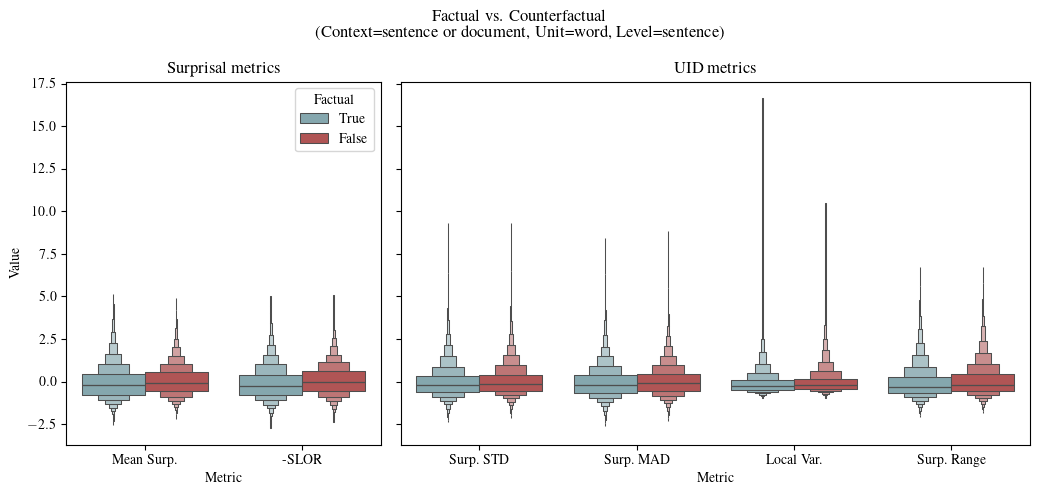

In [203]:
fig, axs = plt.subplots(1, 2, figsize=(10.5, 5), sharey=True, width_ratios=[1, 2])
hue_order = [True, False]
# surp metrics
sns.boxenplot(data=cf_comparison.melt(
       id_vars=['factual'],
       value_vars=surprisal_metrics,
       var_name='Metric',
       value_name='Value'
       ),
        hue='factual', y='Value', x='Metric', ax=axs[0], palette=factuality_cmap, hue_order=hue_order,
        showfliers=False)
axs[0].set_title(f"Surprisal metrics")
handles, labels = axs[0].get_legend_handles_labels()
axs[0].set_xticks(ticks=surprisal_metrics, labels=surprisal_metrics_formatted)
axs[0].legend(title="Factual")
# axs[0].get_legend().remove()

# uid metrics
sns.boxenplot(data=cf_comparison.melt(
       id_vars=['factual'],
       value_vars=uid_metrics,
       var_name='Metric',
       value_name='Value'
       ),
        hue='factual', y='Value', x='Metric', ax=axs[1], palette=factuality_cmap, hue_order=hue_order,
        showfliers=False)
axs[1].set_title(f"UID metrics")
handles, labels = axs[1].get_legend_handles_labels()
# axs[1].legend(title="Factual", bbox_to_anchor=(1.2, 1.0))
axs[1].set_xticks(ticks=uid_metrics, labels=uid_metrics_formatted)
# axs[1].set_xlabel("")
axs[1].get_legend().remove()

# entire plot
plt.suptitle(f"Factual vs. Counterfactual\n(Context={' or '.join(context_lvls)}, Unit={uid_unit}, Level={uid_level})")
plt.tight_layout()
fig.savefig("../plots/fact_cfact_metrics" + plot_suffix,
            dpi=200, bbox_inches='tight')

In [204]:
(cf_comparison.groupby(['doc_name', 'sent_idx'])['context'].count() == 4).mean()

np.float64(1.0)

In [256]:
get_diff = lambda s: s.diff().iloc[1]
get_diff_flipped = lambda s: -s.diff().iloc[1]
agg_map = dict(zip(metrics, [get_diff] * len(metrics)))
agg_map.update({
    'conversion': lambda s: 'A to P' if 'A to P' in s.unique() else 'P to A',
    'passive': lambda s: s.iloc[0]
})
pw_diffs = (cf_comparison
            .sort_values(by='factual', ascending=False) # Always Counterfactual - Factual, shows shift
            .groupby(['doc_name','sent_idx', 'context'])
            [metrics + ['conversion', 'passive']]
            .aggregate(
                agg_map
                )
            .reset_index())
pw_diffs = pw_diffs[pw_diffs['surp_mean'] != 0]
pw_diffs['context_conversion'] = pw_diffs['context'] + pw_diffs['conversion']
pw_diffs

,doc_name,sent_idx,context,surp_mean,surp_slor,uid_std,uid_mad,uid_pwd,uid_range,conversion,passive,context_conversion
2,GUM_academic_art,11,document,0.059805,0.262695,-0.064312,0.029431,0.050490,0.091301,A to P,False,documentA to P
3,GUM_academic_art,11,sentence,-0.062297,0.139277,-0.170160,0.093602,0.091692,0.018778,A to P,False,sentenceA to P
4,GUM_academic_art,16,document,0.094249,0.017944,-0.096467,0.057091,-0.026847,-0.004102,A to P,False,documentA to P
5,GUM_academic_art,16,sentence,0.098738,0.022482,0.105401,0.321354,0.025947,0.070497,A to P,False,sentenceA to P
6,GUM_academic_art,17,document,0.122918,0.319000,0.298469,0.196714,0.004406,0.700489,A to P,False,documentA to P
...,...,...,...,...,...,...,...,...,...,...,...,...
4873,GUM_whow_skittles,52,sentence,0.033435,0.089921,-0.146685,-0.283584,-0.121197,0.017153,A to P,False,sentenceA to P
4874,GUM_whow_skittles,53,document,0.290453,0.374341,0.152971,0.002881,-0.055320,0.827206,A to P,False,documentA to P
4875,GUM_whow_skittles,53,sentence,0.169536,0.252120,0.059595,-0.205700,0.008811,0.663163,A to P,False,sentenceA to P
4876,GUM_whow_skittles,64,document,0.141144,0.186060,-0.085024,-0.047521,0.001996,-0.114559,A to P,False,documentA to P


In [257]:
(pw_diffs['surp_mean'] == 0).mean()

np.float64(0.0)

In [258]:
pw_diffs['conversion'].value_counts(normalize=True)

conversion
A to P    0.934317
P to A    0.065683
Name: proportion, dtype: float64

In [259]:
pw_diffs_resampled = pd.concat([
    pw_diffs[pw_diffs['conversion'] == 'A to P'].sample((pw_diffs['conversion'] == 'P to A').sum(), replace=False),
    pw_diffs[pw_diffs['conversion'] == 'P to A']
])
pw_diffs_resampled['conversion'].value_counts(normalize=True)

conversion
A to P    0.5
P to A    0.5
Name: proportion, dtype: float64

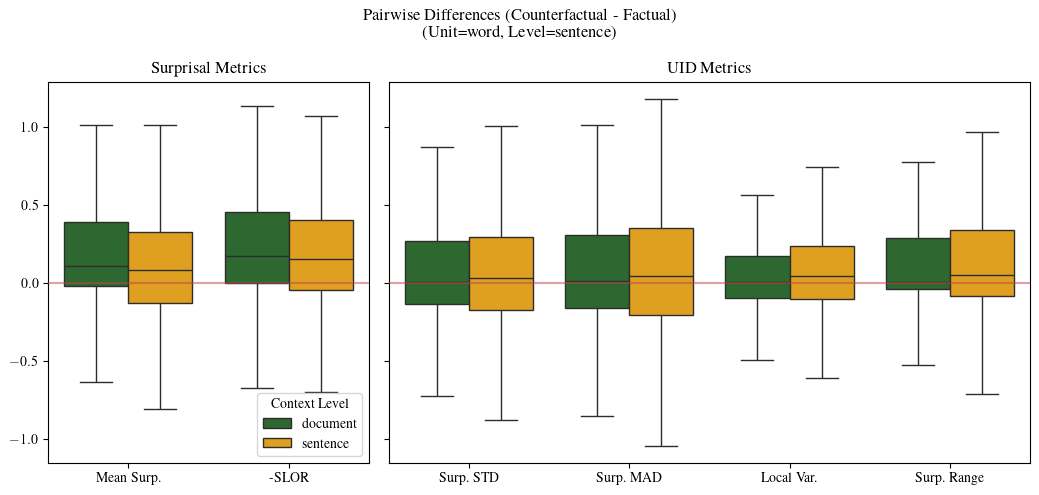

In [260]:
fig, axs = plt.subplots(1, 2, figsize=(10.5, 5), sharey=True, width_ratios=[1, 2])
# surp metrics
sns.boxplot((pw_diffs[['doc_name', 'sent_idx', 'conversion', 'context'] + surprisal_metrics]
             .melt(id_vars=['doc_name', 'sent_idx', 'conversion', 'context'])), 
            y='value', x='variable', 
            # color=conversion_cmap['Both'],
            hue='context', palette=context_cmap,
            showfliers=False,
            # inner=None
            ax=axs[0]
            )
axs[0].axhline(y=0, color='#BF4646', 
            # linestyle='dotted', 
            alpha=0.5,
            zorder=5)
axs[0].set_title("Surprisal Metrics")
axs[0].set_ylabel('')
axs[0].set_xlabel('')
axs[0].legend(title="Context Level")
axs[0].set_xticks(ticks=surprisal_metrics, labels=surprisal_metrics_formatted)

# uid metrics
sns.boxplot((pw_diffs[['doc_name', 'sent_idx', 'conversion', 'context'] + uid_metrics]
             .melt(id_vars=['doc_name', 'sent_idx', 'conversion', 'context'])), 
            y='value', x='variable', 
            # color=conversion_cmap['Both'],
            hue='context', palette=context_cmap,
            showfliers=False,
            # inner=None
            ax=axs[1]
            )
axs[1].axhline(y=0, color='#BF4646', 
            # linestyle='dotted', 
            alpha=0.5,
            zorder=5)
axs[1].set_title("UID Metrics")
axs[1].set_ylabel('')
axs[1].set_xlabel('')
axs[1].get_legend().remove()
axs[1].set_xticks(ticks=uid_metrics, labels=uid_metrics_formatted)
# ax.grid(axis='x')
# full plot
plt.suptitle(f"Pairwise Differences (Counterfactual - Factual)\n(Unit={uid_unit}, Level={uid_level})")
plt.tight_layout()
plt.savefig("../plots/pw_diffs_context" + plot_suffix,
            dpi=100, bbox_inches='tight')

In [261]:
pw_diffs[metrics].median()

surp_mean    0.094909
surp_slor    0.161414
uid_std      0.011526
uid_mad      0.020906
uid_pwd      0.015045
uid_range    0.017290
dtype: float64

In [263]:
results = []
for metric in metrics:
    obs, sim, p_val = perm_test(cf_comparison.sort_values('factual'), 
                            'factual', metric, 10000,
                            # test_stat=lambda a, b: b-a,
                            # compare_fn=lambda sim, obs: sim >= obs
                            )
    results.append({
        "Metric": metrics_mapping[metric],
        "P-value": p_val,
        "Observed abs. diff": obs,
        "Simulated abs. diff": sim
    })
results = pd.DataFrame(results)

Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True


In [264]:
output_name = "../plots/diff_means_perm" + plot_suffix + ".md"
(results.drop(columns="Simulated abs. diff")
 .round(decimals=2)
 .set_index("Metric")
 .to_markdown(buf=output_name))
with open(output_name, 'r', encoding='utf-8') as fh:
    content = fh.read()
display(Markdown(content))

| Metric      |   P-value |   Observed abs. diff |
|:------------|----------:|---------------------:|
| Mean Surp.  |         0 |                 0.12 |
| -SLOR       |         0 |                 0.18 |
| Surp. STD   |         0 |                 0.09 |
| Surp. MAD   |         0 |                 0.08 |
| Local Var.  |         0 |                 0.06 |
| Surp. Range |         0 |                 0.14 |

In [26]:
results = []
for metric in metrics:
    metric_diffs = pw_diffs[metric]
    normal_res = normaltest(metric_diffs)
    factuals = cf_comparison.loc[cf_comparison['factual']]
    cfactuals = cf_comparison.loc[~cf_comparison['factual']]
    ttest_res = ttest_rel(factuals[metric], cfactuals[metric],
                          alternative="greater"
                          )
    results.append({
        'Metric': metrics_mapping[metric],
        'Normality TS': normal_res.statistic,
        'Normality P-val': normal_res.pvalue,
        'Paired-t TS': ttest_res.statistic,
        'Paired-t P-val': ttest_res.pvalue
    })
results = pd.DataFrame(results)

In [27]:
output_name = "../plots/norm_pairedt" + plot_suffix + ".md"
(results
 .round(decimals=2)
 .set_index("Metric")
 .to_markdown(buf=output_name))
with open(output_name, 'r', encoding='utf-8') as fh:
    content = fh.read()
display(Markdown(content))

| Metric      |   Normality TS |   Normality P-val |   Paired-t TS |   Paired-t P-val |
|:------------|---------------:|------------------:|--------------:|-----------------:|
| Mean Surp.  |         282.6  |                 0 |         -7.11 |                1 |
| SLOR        |         226.41 |                 0 |         14.2  |                0 |
| Surp. STD   |         599.59 |                 0 |         -8.37 |                1 |
| Surp. MAD   |         419.25 |                 0 |         -7.06 |                1 |
| Local Var.  |        1796.95 |                 0 |         -6.48 |                1 |
| Surp. Range |         670.11 |                 0 |        -13.59 |                1 |

In [28]:
print(results
 .round(decimals=2)
 .set_index("Metric")
 .to_latex()
)

\begin{tabular}{lrrrr}
\toprule
 & Normality TS & Normality P-val & Paired-t TS & Paired-t P-val \\
Metric &  &  &  &  \\
\midrule
Mean Surp. & 282.600000 & 0.000000 & -7.110000 & 1.000000 \\
SLOR & 226.410000 & 0.000000 & 14.200000 & 0.000000 \\
Surp. STD & 599.590000 & 0.000000 & -8.370000 & 1.000000 \\
Surp. MAD & 419.250000 & 0.000000 & -7.060000 & 1.000000 \\
Local Var. & 1796.950000 & 0.000000 & -6.480000 & 1.000000 \\
Surp. Range & 670.110000 & 0.000000 & -13.590000 & 1.000000 \\
\bottomrule
\end{tabular}



In [29]:
factual_passives_sample = cf_comparison[cf_comparison['passive'] & cf_comparison['factual']].sample(n=cf_comparison['factual'].sum(), replace=True)
factual_actives_sample = cf_comparison[~cf_comparison['passive'] & cf_comparison['factual']].sample(n=cf_comparison['factual'].sum(), replace=True)
pass_vs_act = pd.concat([factual_passives_sample, factual_actives_sample])

In [30]:
results = []
for metric in metrics:
    obs, sim, p_val = perm_test(pass_vs_act, 'passive', metric, 10000,
                            test_stat=lambda a, b: b-a,
                            compare_fn=lambda sim, obs: sim >= obs)
    results.append({
        "metric": metric,
        "pval": p_val,
        "observed": obs,
        "simulated": sim
    })
results = pd.DataFrame(results)

Labels in order:  True False
Labels in order:  True False
Labels in order:  True False
Labels in order:  True False
Labels in order:  True False
Labels in order:  True False


In [31]:
print(results[['metric', 'observed', 'pval']].to_markdown())

|    | metric    |   observed |   pval |
|---:|:----------|-----------:|-------:|
|  0 | surp_mean |  0.34828   | 0      |
|  1 | surp_slor | -0.50543   | 1      |
|  2 | uid_std   | -0.181755  | 1      |
|  3 | uid_mad   | -0.129262  | 1      |
|  4 | uid_pwd   | -0.0802961 | 0.9994 |
|  5 | uid_range | -0.365734  | 1      |


### Passive vs. Active

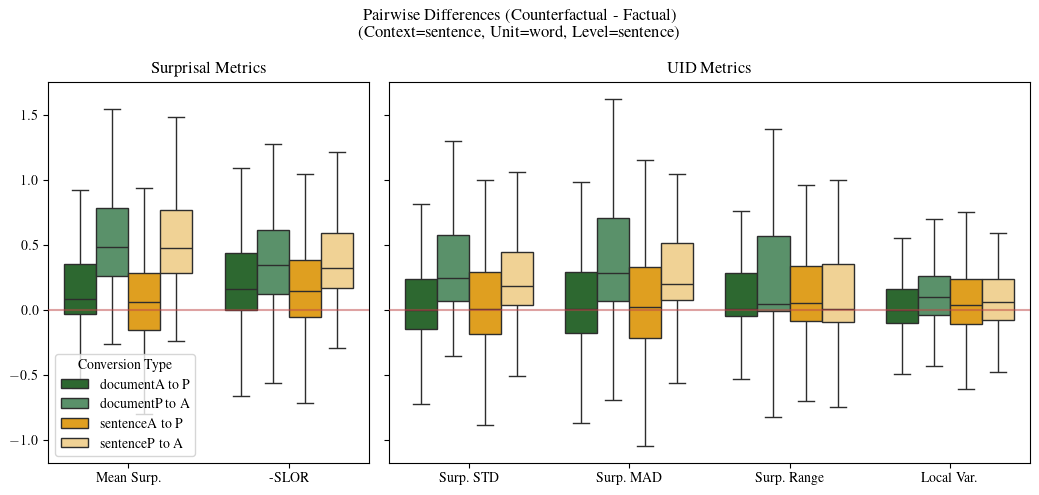

In [216]:
fig, axs = plt.subplots(1, 2, figsize=(10.5, 5), sharey=True, width_ratios=[1, 2])
# surp metrics
sns.boxplot((pw_diffs[['doc_name', 'sent_idx', 'conversion', 'context_conversion'] + surprisal_metrics]
             .melt(id_vars=['doc_name', 'sent_idx', 'conversion', 'context_conversion'])
             .sort_values('context_conversion')), 
            y='value', x='variable', 
            palette=context_cmap, hue='context_conversion', # Look at context + conversion
            # palette=conversion_cmap, hue='conversion', # Look at conversion only across all contexts
            showfliers=False,
            # inner=None
            ax=axs[0]
            )
axs[0].axhline(y=0, color='#BF4646', 
            # linestyle='dotted', 
            alpha=0.5,
            zorder=5)
axs[0].set_title("Surprisal Metrics")
axs[0].set_ylabel('')
axs[0].set_xlabel('')
# axs[0].legend(title="Context Level : Conversion Type")
axs[0].legend(title="Conversion Type")
axs[0].set_xticks(ticks=surprisal_metrics, labels=surprisal_metrics_formatted)

# uid metrics
sns.boxplot((pw_diffs[['doc_name', 'sent_idx', 'conversion', 'context_conversion'] + uid_metrics]
             .melt(id_vars=['doc_name', 'sent_idx', 'conversion', 'context_conversion'])
             .sort_values('context_conversion')), 
            y='value', x='variable', 
            palette=context_cmap, hue='context_conversion', # Look at context + conversion
            # palette=conversion_cmap, hue='conversion', # Look at conversion only across all contexts
            showfliers=False,
            # inner=None
            ax=axs[1]
            )
axs[1].axhline(y=0, color='#BF4646', 
            # linestyle='dotted', 
            alpha=0.5,
            zorder=5)
axs[1].set_title("UID Metrics")
axs[1].set_ylabel('')
axs[1].set_xlabel('')
axs[1].get_legend().remove()
axs[1].set_xticks(ticks=uid_metrics, labels=uid_metrics_formatted)
# ax.grid(axis='x')
# full plot
plt.suptitle(f"Pairwise Differences (Counterfactual - Factual)\n(Context={context_lvl}, Unit={uid_unit}, Level={uid_level})")
plt.tight_layout()
plt.savefig("../plots/pw_diffs_pass-v-act" + plot_suffix,
            dpi=100, bbox_inches='tight')

#### Difference in differences between contexts

In [213]:
pw_diffs.head()

,doc_name,sent_idx,context,surp_mean,surp_slor,uid_std,uid_mad,uid_pwd,uid_range,conversion,context_conversion
2,GUM_academic_art,11,document,0.059805,0.262695,-0.064312,0.029431,0.050490,0.091301,A to P,documentA to P
3,GUM_academic_art,11,sentence,-0.062297,0.139277,-0.170160,0.093602,0.091692,0.018778,A to P,sentenceA to P
4,GUM_academic_art,16,document,0.094249,0.017944,-0.096467,0.057091,-0.026847,-0.004102,A to P,documentA to P
5,GUM_academic_art,16,sentence,0.098738,0.022482,0.105401,0.321354,0.025947,0.070497,A to P,sentenceA to P
6,GUM_academic_art,17,document,0.122918,0.319000,0.298469,0.196714,0.004406,0.700489,A to P,documentA to P


In [265]:
diff_in_pw_diffs = (pw_diffs
    .groupby(['doc_name', 'sent_idx'])
    .filter(lambda g: g.shape[0] >= 2)
    .sort_values(by='context', ascending=False) # Always document - sentence, shows remaining diff
    .groupby(['doc_name','sent_idx'])
    [metrics + ['conversion', 'passive']]
    .aggregate(
        agg_map
        )
    .reset_index())
diff_in_pw_diffs.head(3)

,doc_name,sent_idx,surp_mean,surp_slor,uid_std,uid_mad,uid_pwd,uid_range,conversion,passive
0,GUM_academic_art,11,0.122102,0.123418,0.105848,-0.064170,-0.041202,0.072523,A to P,False
1,GUM_academic_art,16,-0.004489,-0.004538,-0.201868,-0.264263,-0.052795,-0.074599,A to P,False
2,GUM_academic_art,17,0.232918,0.235429,0.257614,-0.001112,0.045236,0.743805,A to P,False


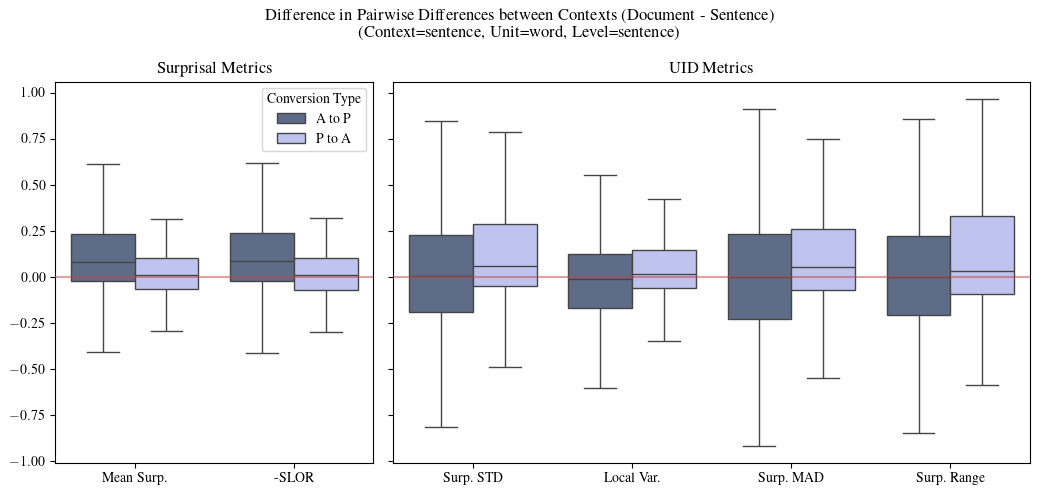

In [266]:
fig, axs = plt.subplots(1, 2, figsize=(10.5, 5), sharey=True, width_ratios=[1, 2])
# surp metrics
sns.boxplot((diff_in_pw_diffs[['doc_name', 'sent_idx', 'conversion',] + surprisal_metrics]
             .melt(id_vars=['doc_name', 'sent_idx', 'conversion',])
             .sort_values('conversion')), 
            y='value', x='variable', 
            # palette=context_cmap, hue='context_conversion', # Look at context + conversion
            palette=conversion_cmap, hue='conversion', # Look at conversion only across all contexts
            showfliers=False,
            # inner=None
            ax=axs[0]
            )
axs[0].axhline(y=0, color='#BF4646', 
            # linestyle='dotted', 
            alpha=0.5,
            zorder=5)
axs[0].set_title("Surprisal Metrics")
axs[0].set_ylabel('')
axs[0].set_xlabel('')
# axs[0].legend(title="Context Level : Conversion Type")
axs[0].legend(title="Conversion Type")
axs[0].set_xticks(ticks=surprisal_metrics, labels=surprisal_metrics_formatted)

# uid metrics
sns.boxplot((diff_in_pw_diffs[['doc_name', 'sent_idx', 'conversion',] + uid_metrics]
             .melt(id_vars=['doc_name', 'sent_idx', 'conversion',])
             .sort_values('conversion')), 
            y='value', x='variable', 
            # palette=context_cmap, hue='context_conversion', # Look at context + conversion
            palette=conversion_cmap, hue='conversion', # Look at conversion only across all contexts
            showfliers=False,
            # inner=None
            ax=axs[1]
            )
axs[1].axhline(y=0, color='#BF4646', 
            # linestyle='dotted', 
            alpha=0.5,
            zorder=5)
axs[1].set_title("UID Metrics")
axs[1].set_ylabel('')
axs[1].set_xlabel('')
axs[1].get_legend().remove()
axs[1].set_xticks(ticks=uid_metrics, labels=uid_metrics_formatted)
# ax.grid(axis='x')
# full plot
plt.suptitle(f"Difference in Pairwise Differences between Contexts (Document - Sentence)\n(Context={context_lvl}, Unit={uid_unit}, Level={uid_level})")
plt.tight_layout()
plt.savefig("../plots/diff_in_pw_diffs_pass-v-act" + plot_suffix,
            dpi=100, bbox_inches='tight')

For A to P, difference in uniformity metric differences is large after including more context, but difference in uid metric differences is not.
This suggests that the counterfactual Passive sentences are even more surprising but not any less uniform after taking discourse context into account.

For P to A, it's the opposite.
Counterfactual Active sentences don't become more or less surprising given the prior context.
However, they do become even less uniform than before.

What if we look at the differences between sentence surprisal/UID before and after including context *separately* for factual and counterfactual sentences?
- For factual sentences, we expect surprisals to decrease after including context, and potentially for uniformity to increase as well. It'd be surprising to see significant decrease in uniformity or increase in surprisal.
- For counterfactual, we probably expect surprisals increase a lot. In fact, in a void, counterfactual sentences shouldn't be any much surprising than their factual counterparts, whereas with context, they should be a lot more surprising. Same goes for uniformity, but in opposite directions - we expect it to decrease with context.

In [293]:
context_diffs = (cf_comparison
    .groupby(['doc_name', 'sent_idx', 'factual'])
    .filter(lambda g: g.shape[0] >= 2)
    .sort_values(by='context', ascending=False) # Always document - sentence, shows remaining diff
    .groupby(['doc_name', 'sent_idx', 'factual'])
    [metrics + ['conversion', 'passive']]
    .aggregate(
        agg_map
        )
    .reset_index())
context_diffs_factual = context_diffs[context_diffs['factual']]
context_diffs_counterfactual = context_diffs[~context_diffs['factual']]
context_diffs.head(3)

,doc_name,sent_idx,factual,surp_mean,surp_slor,uid_std,uid_mad,uid_pwd,uid_range,conversion,passive
0,GUM_academic_art,8,False,-0.644482,-0.651429,-0.349701,-0.206096,-0.272368,-0.714151,A to P,True
1,GUM_academic_art,8,True,-0.644482,-0.651429,-0.349701,-0.206096,-0.272368,-0.714151,A to P,False
2,GUM_academic_art,11,False,-0.192951,-0.195031,0.072656,0.275180,-0.007837,0.013598,A to P,True


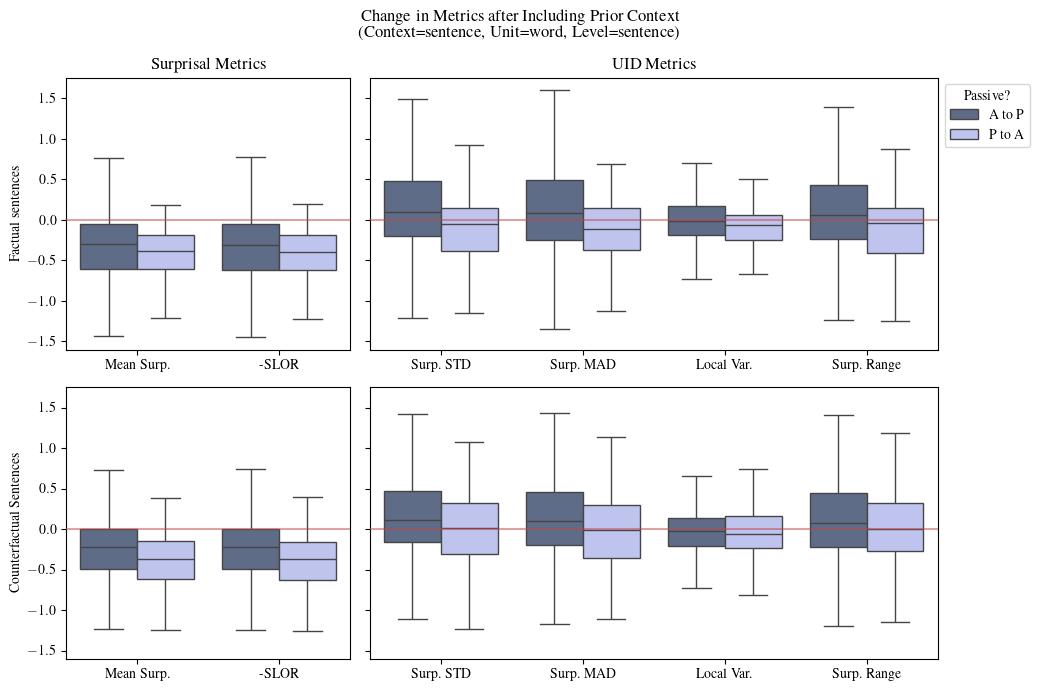

In [294]:
fig, axs = plt.subplots(2, 2, figsize=(10.5, 7), sharey=True, width_ratios=[1, 2])
axs = [ax for row in axs for ax in row]
cmap, hue_variable = (
    # passive_cmap, 'passive'
    conversion_cmap, 'conversion'
)
id_vars = [hue_variable]
sort_asc = True
## Factual
# surp metrics
sns.boxplot((context_diffs_factual[id_vars + surprisal_metrics]
             .melt(id_vars=id_vars)
             .sort_values(hue_variable, ascending=sort_asc)), 
            y='value', x='variable', 
            palette=cmap, hue=hue_variable,
            showfliers=False,
            # inner=None
            ax=axs[0]
            )
axs[0].axhline(y=0, color='#BF4646', 
            # linestyle='dotted', 
            alpha=0.5,
            zorder=5)
axs[0].set_title("Surprisal Metrics")
axs[0].set_ylabel('Factual sentences')
axs[0].set_xlabel('')
# axs[0].legend(title="Context Level : Conversion Type")
axs[0].get_legend().remove()
axs[0].set_xticks(ticks=surprisal_metrics, labels=surprisal_metrics_formatted)

# uid metrics
sns.boxplot((context_diffs_factual[id_vars + uid_metrics]
             .melt(id_vars=id_vars)
             .sort_values(hue_variable, ascending=sort_asc)), 
            y='value', x='variable', 
            order=uid_metrics,
            palette=cmap, hue=hue_variable,
            showfliers=False,
            # inner=None
            ax=axs[1]
            )
axs[1].axhline(y=0, color='#BF4646', 
            # linestyle='dotted', 
            alpha=0.5,
            zorder=5)
axs[1].set_title("UID Metrics")
axs[1].set_ylabel('')
axs[1].set_xlabel('')
axs[1].legend(title="Passive?", bbox_to_anchor=(1,1))
axs[1].set_xticks(ticks=uid_metrics, labels=uid_metrics_formatted)

## Counterfactual
# surp metrics
sns.boxplot((context_diffs_counterfactual[id_vars + surprisal_metrics]
             .melt(id_vars=id_vars)
             .sort_values(hue_variable, ascending=sort_asc)), 
            y='value', x='variable', 
            palette=cmap, hue=hue_variable,
            showfliers=False,
            # inner=None
            ax=axs[2]
            )
axs[2].axhline(y=0, color='#BF4646', 
            # linestyle='dotted', 
            alpha=0.5,
            zorder=5)
axs[2].set_ylabel('Counterfactual Sentences')
axs[2].set_xlabel('')
# axs[2].legend(title="Context Level : Conversion Type")
axs[2].get_legend().remove()
axs[2].set_xticks(ticks=surprisal_metrics, labels=surprisal_metrics_formatted)

# uid metrics
sns.boxplot((context_diffs_counterfactual[id_vars + uid_metrics]
             .melt(id_vars=id_vars)
             .sort_values(hue_variable, ascending=sort_asc)), 
            y='value', x='variable', 
            order=uid_metrics,
            palette=cmap, hue=hue_variable,
            showfliers=False,
            # inner=None
            ax=axs[3]
            )
axs[3].axhline(y=0, color='#BF4646', 
            # linestyle='dotted', 
            alpha=0.5,
            zorder=5)
axs[3].set_ylabel('')
axs[3].set_xlabel('')
axs[3].get_legend().remove()
axs[3].set_xticks(ticks=uid_metrics, labels=uid_metrics_formatted)
# ax.grid(axis='x')
# full plot
plt.suptitle(f"Change in Metrics after Including Prior Context\n(Context={context_lvl}, Unit={uid_unit}, Level={uid_level})")
plt.tight_layout()
plt.savefig("../plots/pw_diffs_context_factual_pass-v-act" + plot_suffix,
            dpi=100, bbox_inches='tight')

This aligns with what we expected.
Surprisal lowers for both counterfactual and factual sentences given more context, but less so for counterfactual.
Uniformity also generally increases for factual sentences, but stays the same/decreases for counterfactual.

There is still an asymmetry based on conversion direction. In the A to P case, both factual and counterfactual sentences seem to increase in uniformity with more prior context.

In [302]:
results = []
for metric in metrics:
    obs, sim, p_val = perm_test(context_diffs, 
                            'factual', 
                            metric, 
                            1000,
                            )
    results.append({
        "Metric": metrics_mapping[metric],
        "P-value": p_val,
        "Observed abs. diff": obs,
        # "Simulated abs. diff": sim
    })
results = pd.DataFrame(results)
results

Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True


,Metric,P-value,Observed abs. diff
0,Mean Surp.,0.000,0.097408
1,-SLOR,0.000,0.098458
2,Surp. STD,0.532,0.014231
3,Surp. MAD,0.949,0.001667
4,Local Var.,0.584,0.010958
5,Surp. Range,0.224,0.025502


These test results show that the mean changes in uid metrics after adding prior context are not significantly different between factual and counterfactual sentences, but are significant in surprisal metrics.
This suggests that adding context has different effects on surprisal for factual and counterfactual sentences, but the same effect on uniformity.

In [305]:
results = []
for metric in surprisal_metrics:
    obs, sim, p_val = perm_test(context_diffs, 
                            'factual', 
                            metric, 
                            1000,
                            test_stat=lambda a, b: a - b,
                            compare_fn=lambda sim, obs: sim >= obs
                            )
    results.append({
        "Metric": metrics_mapping[metric],
        "P-value": p_val,
        "Observed abs. diff": obs,
        # "Simulated abs. diff": sim
    })
results = pd.DataFrame(results)
results

Labels in order:  False True
Labels in order:  False True


,Metric,P-value,Observed abs. diff
0,Mean Surp.,0.0,0.097408
1,-SLOR,0.0,0.098458


There is significantly less of a decrease in surprisal in factual sentences after giving more context than counterfactual sentences.

In [303]:
perm_test

<function __main__.perm_test(data, label_column, value_column, n_permutations, agg_fn=<function mean at 0x1064cab70>, test_stat=<function <lambda> at 0x112e1b7e0>, compare_fn=<function <lambda> at 0x314a40f40>)>

#### Statistical Tests

In [164]:
results = []
for metric in metrics:
    p_to_a = cf_comparison[cf_comparison['conversion']=='P to A'].sort_values('factual')
    a_to_p = cf_comparison[cf_comparison['conversion']=='A to P'].sort_values('factual')
    for data in [p_to_a, a_to_p]:
        obs, sim, p_val = perm_test(data, 
                                'factual', 
                                metric, 
                                10000,
                                )
        results.append({
            "Metric": metrics_mapping[metric],
            "Conversion Type": data['conversion'].unique()[0],
            "P-value": p_val,
            "Observed abs. diff": obs,
            "Simulated abs. diff": sim
        })
results = pd.DataFrame(results)

Labels in order:  False True
Labels in order:  False True
Labels in order:  False True


KeyboardInterrupt: 

In [34]:
output_name = "../plots/diff_means_perm_pass-v-act" + plot_suffix + ".md"
(results.drop(columns="Simulated abs. diff")
 .round(decimals=2)
 .set_index("Metric")
 .to_markdown(buf=output_name))
with open(output_name, 'r', encoding='utf-8') as fh:
    content = fh.read()
display(Markdown(content))

| Metric      | Conversion Type   |   P-value |   Observed abs. diff |
|:------------|:------------------|----------:|---------------------:|
| Mean Surp.  | P to A            |      0    |                 0.61 |
| Mean Surp.  | A to P            |      0.23 |                 0.04 |
| SLOR        | P to A            |      0    |                 0.45 |
| SLOR        | A to P            |      0    |                 0.11 |
| Surp. STD   | P to A            |      0.03 |                 0.21 |
| Surp. STD   | A to P            |      0.02 |                 0.07 |
| Surp. MAD   | P to A            |      0.01 |                 0.25 |
| Surp. MAD   | A to P            |      0.03 |                 0.07 |
| Local Var.  | P to A            |      0.46 |                 0.05 |
| Local Var.  | A to P            |      0.04 |                 0.06 |
| Surp. Range | P to A            |      0.17 |                 0.15 |
| Surp. Range | A to P            |      0    |                 0.11 |

In [35]:
results = []
for metric in metrics:
    for conv in ['P to A', 'A to P']:
        metric_diffs = pw_diffs.loc[pw_diffs['conversion']==conv, metric]
        normal_res = normaltest(metric_diffs)
        factuals = cf_comparison.loc[cf_comparison['factual'] 
                                     & (cf_comparison['conversion']==conv)]
        cfactuals = cf_comparison.loc[~cf_comparison['factual']
                                      & (cf_comparison['conversion']==conv)]
        ttest_res = ttest_rel(factuals[metric], cfactuals[metric],
                            alternative="less"
                            )
        results.append({
            'Metric': metrics_mapping[metric],
            'Conversion Type': conv,
            'Normality TS': normal_res.statistic,
            'Normality P-val': normal_res.pvalue,
            'Paired-t TS': ttest_res.statistic,
            'Paired-t P-val': ttest_res.pvalue
        })
results = pd.DataFrame(results)

In [36]:
output_name = "../plots/norm_pairedt_pass-v-act" + plot_suffix + ".md"
(results
 .round(decimals=2)
 .set_index("Metric")
 .to_markdown(buf=output_name))
with open(output_name, 'r', encoding='utf-8') as fh:
    content = fh.read()
display(Markdown(content))

| Metric      | Conversion Type   |   Normality TS |   Normality P-val |   Paired-t TS |   Paired-t P-val |
|:------------|:------------------|---------------:|------------------:|--------------:|-----------------:|
| Mean Surp.  | P to A            |         107.29 |                 0 |        -11.88 |             0    |
| Mean Surp.  | A to P            |         349    |                 0 |         -3.83 |             0    |
| SLOR        | P to A            |         109.8  |                 0 |          9.56 |             1    |
| SLOR        | A to P            |         189.72 |                 0 |         12.16 |             1    |
| Surp. STD   | P to A            |          62.97 |                 0 |         -5.6  |             0    |
| Surp. STD   | A to P            |         560.66 |                 0 |         -7.31 |             0    |
| Surp. MAD   | P to A            |          15.03 |                 0 |         -6.35 |             0    |
| Surp. MAD   | A to P            |         405.69 |                 0 |         -5.9  |             0    |
| Local Var.  | P to A            |          53.38 |                 0 |         -1.63 |             0.05 |
| Local Var.  | A to P            |        1700.73 |                 0 |         -6.28 |             0    |
| Surp. Range | P to A            |          90.2  |                 0 |         -3.29 |             0    |
| Surp. Range | A to P            |         563.54 |                 0 |        -13.24 |             0    |

In [37]:
print(results.loc[results['Conversion Type']=='A to P', 
                  ['Metric', 'Normality TS', 'Normality P-val', 'Paired-t TS', 'Paired-t P-val']]
 .round(decimals=2)
 .set_index("Metric")
 .to_latex())

\begin{tabular}{lrrrr}
\toprule
 & Normality TS & Normality P-val & Paired-t TS & Paired-t P-val \\
Metric &  &  &  &  \\
\midrule
Mean Surp. & 349.000000 & 0.000000 & -3.830000 & 0.000000 \\
SLOR & 189.720000 & 0.000000 & 12.160000 & 1.000000 \\
Surp. STD & 560.660000 & 0.000000 & -7.310000 & 0.000000 \\
Surp. MAD & 405.690000 & 0.000000 & -5.900000 & 0.000000 \\
Local Var. & 1700.730000 & 0.000000 & -6.280000 & 0.000000 \\
Surp. Range & 563.540000 & 0.000000 & -13.240000 & 0.000000 \\
\bottomrule
\end{tabular}



## Document-level

In [38]:
def extract_sents_of_interest_document_lvl(doc_sents: pd.DataFrame):
    converted_indices = doc_sents['conv_idx'].unique()
    sents_of_interest = []
    for i, sent in doc_sents.iterrows():
        if (sent['conv_idx'] in [sent['sent_idx'], -1]):
            sents_of_interest.append(sent)
    return pd.DataFrame(sents_of_interest)

def repeat_factuals(group):
    if group['factual'].mean() == 0:
        return None
    factual_values = group[group['factual']]
    counterfactual_values = group[~group['factual']]
    num_cf = counterfactual_values.shape[0]
    repeated = [factual_values] * num_cf
    out = pd.concat(repeated + [counterfactual_values]).reset_index(drop=True)
    return out

def process_diffs(group):
    if group['factual'].mean() == 0:
        return None
    factual_values = group[group['factual']].iloc[0]
    counterfactual_values = group[~group['factual']]
    counterfactual_values[metrics] = - counterfactual_values[metrics] + factual_values[metrics]
    return counterfactual_values

In [39]:
data_path = "../outputs/cf_word_document_uid.csv"
uid_df = pd.read_csv(data_path).iloc[:, 1:]
uid_df.shape

(13474, 15)

In [40]:
_, uid_unit, uid_level, _ = Path(data_path).stem.split("_")
context_lvl = 'document' # has to be document for doc-level analysis
plot_suffix = f"_{uid_unit}_{uid_level}_{context_lvl}"

In [41]:
uid_df[['factual', 'doc_name', 'conv_idx', 'conversion']] = uid_df['doc_id'].str.split("::", expand=True)
uid_df['conv_idx'] = uid_df['conv_idx'].astype(int)
uid_df['sent_idx'] = uid_df['sent_idx'].astype(int)
# str_to_list = lambda s: np.array(s.strip('[').strip(']').split(' ')).astype(float)
def str_to_list(s):
    return eval(s.replace('\0', ''))
uid_df['raw_surps'] = uid_df['raw_surps'].apply(str_to_list)
uid_df['raw_uni_surps'] = uid_df['raw_uni_surps'].apply(str_to_list)

In [42]:
uid_df.shape, uid_df.dtypes

((13474, 19),
 doc_id               str
 sent_idx           int64
 context              str
 sentence             str
 raw_surps         object
 raw_uni_surps     object
 surp_mean        float64
 surp_slor        float64
 uid_std          float64
 uid_mad          float64
 uid_pwd          float64
 uid_range        float64
 uid_cv           float64
 uid_slope        float64
 uid_len            int64
 factual              str
 doc_name             str
 conv_idx           int64
 conversion           str
 dtype: object)

In [43]:
uid_df['context'].unique()

<StringArray>
[    'sentence',        'prev1',        'prev3',     'document',
  'sent[-2,+0]',  'sent[-2,+2]',  'tok[-64,+0]', 'tok[-64,+64]']
Length: 8, dtype: str

In [44]:
sents_of_interest = uid_df.groupby("doc_name").apply(extract_sents_of_interest_document_lvl).reset_index().drop(columns="level_1")
sents_of_interest.shape

(13474, 19)

In [45]:
cf_comparison = sents_of_interest[sents_of_interest['context']==context_lvl]#.drop(columns=['raw_surps', 'raw_uni_surps'])
cf_comparison['factual'] = cf_comparison['factual'] == 'f'
cf_comparison = cf_comparison.groupby(['doc_id', 'sent_idx']).first().sort_values(by=['doc_name', 'sent_idx']).reset_index()
cf_comparison = cf_comparison.groupby('doc_name').filter(lambda g: g.shape[0] > 1)
map_conversion = lambda conv: 'A to P' if conv == 'a>p' else 'P to A' if conv == 'p>a' else conv
cf_comparison['conversion'] = cf_comparison['conversion'].apply(map_conversion)
cf_comparison.shape
# cf_comparison.sort_values(['doc_name', 'sent_idx']).head()

(1541, 19)

In [46]:
standard_scaler = StandardScaler()
cf_comparison[metrics] = standard_scaler.fit_transform(cf_comparison[metrics])

In [47]:
for name in cf_comparison['doc_name'].unique():
    try:
        group = cf_comparison[cf_comparison['doc_name'] == name]
        factual_values = group[group['factual']].iloc[0]
        counterfactual_values = group[~group['factual']]
        counterfactual_values[metrics] = factual_values[metrics] - counterfactual_values[metrics]
    except Exception as e:
        print(e)
        print(name)

single positional indexer is out-of-bounds
GUM_academic_enjambment
single positional indexer is out-of-bounds
GUM_essay_dividends
single positional indexer is out-of-bounds
GUM_fiction_veronique
single positional indexer is out-of-bounds
GUM_news_election
single positional indexer is out-of-bounds
GUM_speech_floyd
single positional indexer is out-of-bounds
GUM_textbook_anthropology
single positional indexer is out-of-bounds
GUM_textbook_spacetime
single positional indexer is out-of-bounds
GUM_vlog_exams


In [48]:
pw_diffs = (cf_comparison
            .groupby(['doc_name'])
            .apply(process_diffs)
            .reset_index())
for metric in metrics:
    pw_diffs[metric] = pw_diffs[metric].astype(float)
pw_diffs.head()

,doc_name,level_1,doc_id,sent_idx,context,sentence,raw_surps,raw_uni_surps,surp_mean,surp_slor,uid_std,uid_mad,uid_pwd,uid_range,uid_cv,uid_slope,uid_len,factual,conv_idx,conversion
0,GUM_academic_art,1,cf::GUM_academic_art::8::a>p,8,document,Do museum labels have an impact on how people ...,"[25.87620449066162, 16.13070511817932, 4.71171...","[16.545324187342086, 16.06773611242024, 5.1889...",0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,1.009614,-0.005310,653,False,8,A to P
1,GUM_academic_art,2,cf::GUM_academic_art::11::a>p,11,document,A collaborative pilot project focusing on a un...,"[25.56213665008545, 16.13070511817932, 4.71171...","[16.545324187342086, 16.06773611242024, 5.1889...",-0.002897,0.011415,0.001614,-0.005473,-0.024353,1.589701e-06,1.009082,-0.005373,655,False,11,A to P
2,GUM_academic_art,3,cf::GUM_academic_art::16::a>p,16,document,The potential implications of these techniques...,"[25.85675811767578, 16.13070511817932, 4.71171...","[16.545324187342086, 16.06773611242024, 5.1889...",-0.012619,0.005211,0.008045,-0.001398,0.005343,-1.799964e-06,1.007149,-0.005255,655,False,16,A to P
3,GUM_academic_art,4,cf::GUM_academic_art::17::a>p,17,document,Established research strengths in Spanish art ...,"[25.812321662902832, 16.13070511817932, 4.7117...","[16.545324187342086, 16.06773611242024, 5.1889...",-0.019261,0.039768,0.007865,-0.000233,0.023719,9.984934e-07,1.006505,-0.005279,655,False,17,A to P
4,GUM_academic_art,5,cf::GUM_academic_art::20::p>a,20,document,An interaction between the goals of the observ...,"[25.78920269012451, 16.13070511817932, 4.71171...","[16.545324187342086, 16.06773611242024, 5.1889...",-0.029838,0.011892,0.004540,0.016274,0.001540,7.225960e-07,1.005928,-0.005370,651,False,20,P to A


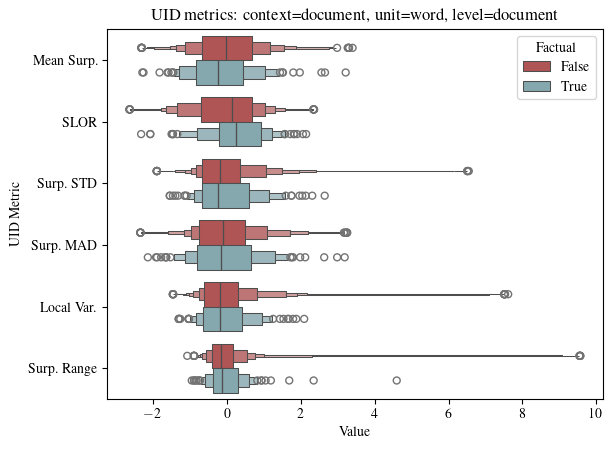

In [49]:
fig, ax = plt.subplots()
sns.boxenplot(data=cf_comparison.melt(
       id_vars=['factual'],
       value_vars=metrics,
       var_name='UID Metric',
       value_name='Value'
       ),
        hue='factual', x='Value', y='UID Metric', ax=ax, palette=factuality_cmap,
        showfliers=True)
plt.title(f"UID metrics: context={context_lvl}, unit={uid_unit}, level={uid_level}")
handles, labels = ax.get_legend_handles_labels()
plt.legend(title="Factual")
ax.set_yticks(ticks=metrics, labels=metrics_formatted)
fig.savefig("../plots/uid_metrics" + plot_suffix,
            dpi=200, bbox_inches='tight')

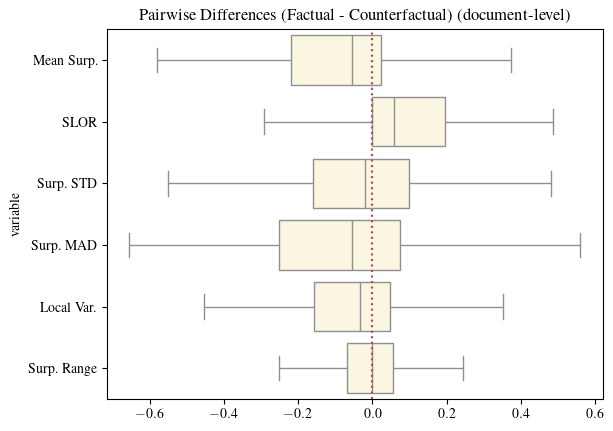

In [50]:
sns.boxplot((pw_diffs[['doc_name', 'sent_idx', 'conversion'] + metrics]
             .melt(id_vars=['doc_name', 'sent_idx', 'conversion'])), 
            x='value', y='variable', 
            color=conversion_cmap['Both'],
            showfliers=False,
            # inner=None
            )
plt.axvline(x=0, color='#BF4646', linestyle='dotted', zorder=5)
plt.title(f"Pairwise Differences (Factual - Counterfactual) ({uid_level}-level)")
plt.xlabel('')
plt.yticks(ticks=metrics, labels=metrics_formatted)
plt.savefig("../plots/pw_diffs_fact-counterfact" + plot_suffix,
            dpi=200, bbox_inches='tight')

In [51]:
results = []
for metric in metrics:
    obs, sim, p_val = perm_test(cf_comparison.sort_values('factual'), 
                            'factual', metric, 10000,
                            # test_stat=lambda a, b: b-a,
                            # compare_fn=lambda sim, obs: sim >= obs
                            )
    results.append({
        "Metric": metrics_mapping[metric],
        "P-value": p_val,
        "Observed abs. diff": obs,
        "Simulated abs. diff": sim
    })
results = pd.DataFrame(results)

Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True
Labels in order:  False True


In [52]:
output_name = "../plots/diff_means_perm" + plot_suffix + ".md"
(results.drop(columns="Simulated abs. diff")
 .round(decimals=2)
 .set_index("Metric")
 .to_markdown(buf=output_name))
with open(output_name, 'r', encoding='utf-8') as fh:
    content = fh.read()
display(Markdown(content))

| Metric      |   P-value |   Observed abs. diff |
|:------------|----------:|---------------------:|
| Mean Surp.  |      0.16 |                 0.13 |
| SLOR        |      0    |                 0.27 |
| Surp. STD   |      0.94 |                 0.01 |
| Surp. MAD   |      0.91 |                 0.01 |
| Local Var.  |      0.48 |                 0.07 |
| Surp. Range |      0.94 |                 0.01 |

In [53]:
cf_repeated = (cf_comparison
               .groupby("doc_name")
               .apply(repeat_factuals)
               .reset_index()
               .sort_values('doc_name'))

In [54]:
results = []
for metric in metrics:
    metric_diffs = pw_diffs[metric]
    normal_res = normaltest(metric_diffs)
    factuals = cf_repeated.loc[cf_repeated['factual']]
    cfactuals = cf_repeated.loc[~cf_repeated['factual']]
    ttest_res = ttest_rel(factuals[metric], cfactuals[metric],
                          alternative="less"
                          )
    results.append({
        'Metric': metrics_mapping[metric],
        'Normality TS': normal_res.statistic,
        'Normality P-val': normal_res.pvalue,
        'Paired-t TS': ttest_res.statistic,
        'Paired-t P-val': ttest_res.pvalue
    })
results = pd.DataFrame(results)

In [55]:
output_name = "../plots/norm_pairedt" + plot_suffix + ".md"
(results
 .round(decimals=2)
 .set_index("Metric")
 .to_markdown(buf=output_name))
with open(output_name, 'r', encoding='utf-8') as fh:
    content = fh.read()
display(Markdown(content))

| Metric      |   Normality TS |   Normality P-val |   Paired-t TS |   Paired-t P-val |
|:------------|---------------:|------------------:|--------------:|-----------------:|
| Mean Surp.  |          61.98 |                 0 |         -9.14 |             0    |
| SLOR        |          25.24 |                 0 |         17.62 |             1    |
| Surp. STD   |        1317.2  |                 0 |         -2.43 |             0.01 |
| Surp. MAD   |         111.38 |                 0 |         -5.55 |             0    |
| Local Var.  |        1740.98 |                 0 |         -5.57 |             0    |
| Surp. Range |        1472.94 |                 0 |         -0.43 |             0.33 |